In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------
# 1 Kalman Filter
# ------------------------------------------------
def kalman_filter(data, Q, R):
    n = len(data)
    x_est = np.zeros(n)
    P = np.zeros(n)

    x_est[0] = data[0]
    P[0] = 1

    for k in range(1, n):
        x_pred = x_est[k-1]
        P_pred = P[k-1] + Q

        K = P_pred / (P_pred + R)
        x_est[k] = x_pred + K * (data[k] - x_pred)
        P[k] = (1 - K) * P_pred

    return x_est


# ------------------------------------------------
# 2 Feature Engineering
# ------------------------------------------------
def prepare_features(df):
    df["speed_sat"] = df["Speed_kmph_filtered"] * df["Sats_filtered"]
    df["altitude_sat_ratio"] = df["Altitude_m_filtered"] / (df["Sats_filtered"] + 1)
    df["hdop_sat_ratio"] = df["HDOPs_filtered"] / (df["Sats_filtered"] + 1)
    return df


# ------------------------------------------------
# 3 Smoothness Metric
# ------------------------------------------------
def signal_smoothness(filtered):
    return np.mean(np.abs(np.diff(filtered)))


# ------------------------------------------------
# 4 Evaluate Model
# ------------------------------------------------
def evaluate_model(df, Q, R):

    df_temp = df.copy()

    # Apply Kalman filter
    for col in ['Speed_kmph', 'Altitude_m', 'Course_deg', 'Sats', 'HDOPs']:
        df_temp[col + "_filtered"] = kalman_filter(df_temp[col].values, Q=Q, R=R)

    # Feature engineering
    df_temp = prepare_features(df_temp)

    features = [
        'Speed_kmph_filtered',
        'Altitude_m_filtered',
        'Course_deg_filtered',
        'Sats_filtered',
        'HDOPs_filtered',
        'speed_sat',
        'altitude_sat_ratio',
        'hdop_sat_ratio'
    ]

    X = df_temp[features]
    y = df_temp["Error_meters"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )

    # ❌ removed verbose
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    smoothness = signal_smoothness(df_temp['Speed_kmph_filtered'].values)

    return r2, rmse, smoothness


# ------------------------------------------------
# 5 Load Dataset
# ------------------------------------------------
df = pd.read_csv("data.csv")

df = df[['Speed_kmph','Altitude_m','Course_deg','Sats','HDOPs','Error_meters']]
df = df.dropna()

print("Dataset shape:", df.shape)


# ------------------------------------------------
# 6 Grid Search
# ------------------------------------------------
Q_values = [1e-5, 1e-4, 1e-3, 1e-2]
R_values = [0.01, 0.1, 0.5, 1]

results = []

for Q in Q_values:
    for R in R_values:
        r2, rmse, smoothness = evaluate_model(df, Q, R)

        results.append({
            "Q": Q,
            "R": R,
            "R2": r2,
            "RMSE": rmse,
            "Smoothness": smoothness
        })

results_df = pd.DataFrame(results)

print("\nAll Results:")
print(results_df)


# ------------------------------------------------
# 7 Select BEST Q, R (SAFE)
# ------------------------------------------------
filtered_df = results_df[results_df["R2"] > 0.7]

if len(filtered_df) == 0:
    print("\n⚠️ No model with R2 > 0.7, selecting best available...")
    best = results_df.sort_values(by="RMSE").iloc[0]
else:
    best = filtered_df.sort_values(by="RMSE").iloc[0]

best_Q = best["Q"]
best_R = best["R"]

print("\nBest Parameters:")
print("Q =", best_Q)
print("R =", best_R)


# ------------------------------------------------
# 8 Final Training
# ------------------------------------------------
for col in ['Speed_kmph', 'Altitude_m', 'Course_deg', 'Sats', 'HDOPs']:
    df[col + "_filtered"] = kalman_filter(df[col].values, Q=best_Q, R=best_R)

df = prepare_features(df)

features = [
    'Speed_kmph_filtered',
    'Altitude_m_filtered',
    'Course_deg_filtered',
    'Sats_filtered',
    'HDOPs_filtered',
    'speed_sat',
    'altitude_sat_ratio',
    'hdop_sat_ratio'
]

X = df[features]
y = df["Error_meters"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

final_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# ❌ removed verbose here too
final_model.fit(X_train, y_train)


# ------------------------------------------------
# 9 Evaluation
# ------------------------------------------------
y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nFinal Model Performance")
print("R2:", r2)
print("RMSE:", rmse)

Dataset shape: (17597, 6)

All Results:
          Q     R        R2      RMSE  Smoothness
0   0.00001  0.01  0.971968  0.812020    0.016558
1   0.00001  0.10  0.978257  0.715147    0.007482
2   0.00001  0.50  0.982255  0.646062    0.004179
3   0.00001  1.00  0.981493  0.659785    0.003260
4   0.00010  0.01  0.955721  1.020558    0.035550
5   0.00010  0.10  0.971961  0.812115    0.016557
6   0.00010  0.50  0.975012  0.766667    0.009556
7   0.00010  1.00  0.978265  0.715017    0.007478
8   0.00100  0.01  0.951602  1.066970    0.075843
9   0.00100  0.10  0.955729  1.020470    0.035549
10  0.00100  0.50  0.973109  0.795326    0.020931
11  0.00100  1.00  0.972010  0.811409    0.016553
12  0.01000  0.01  0.945121  1.136167    0.142511
13  0.01000  0.10  0.951573  1.067287    0.075842
14  0.01000  0.50  0.954718  1.032052    0.044647
15  0.01000  1.00  0.955821  1.019404    0.035546

Best Parameters:
Q = 1e-05
R = 0.5

Final Model Performance
R2: 0.9822551974379288
RMSE: 0.6460621177453227


Dataset shape: (17597, 6)

Model Performance
------------------
R2 Score: 0.9814933891058877
MAE: 0.36522284077250383
RMSE: 0.659784544356796

Feature Importance
               Feature  Importance
4       HDOPs_filtered    0.304658
1  Altitude_m_filtered    0.169281
2  Course_deg_filtered    0.152561
0  Speed_kmph_filtered    0.140532
6   altitude_sat_ratio    0.069679
3        Sats_filtered    0.069414
5            speed_sat    0.068573
7       hdop_sat_ratio    0.025301


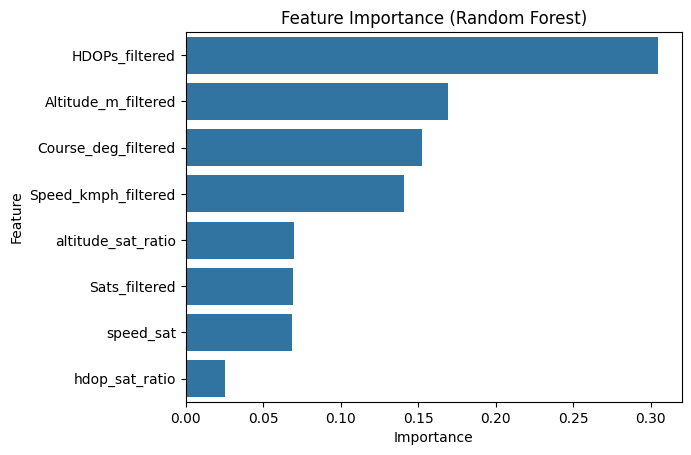

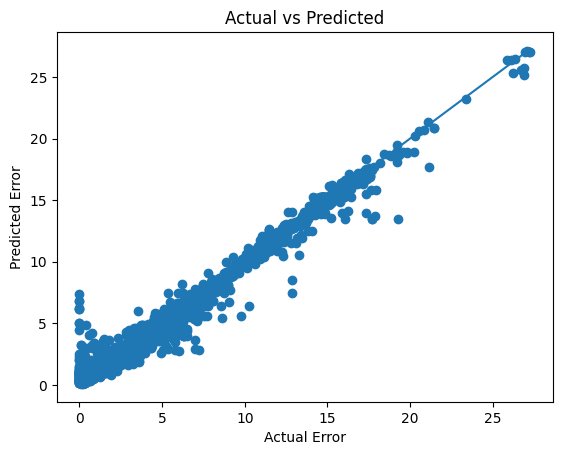

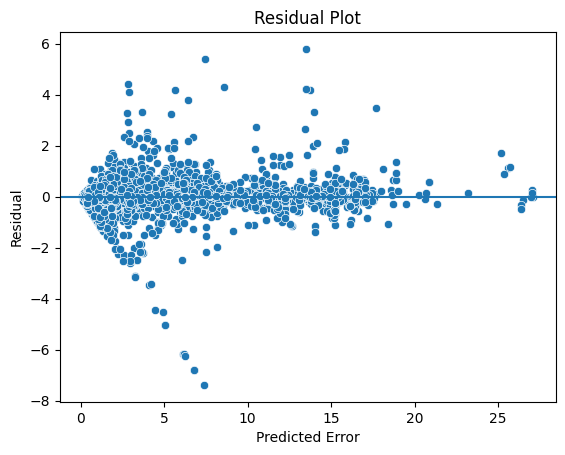

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# ------------------------------------------------
# 1 Kalman Filter Function
# ------------------------------------------------
def kalman_filter(data, Q=1e-5, R=1):
    n = len(data)
    x_est = np.zeros(n)
    P = np.zeros(n)

    x_est[0] = data[0]
    P[0] = 1

    for k in range(1, n):
        # Prediction
        x_pred = x_est[k-1]
        P_pred = P[k-1] + Q

        # Update
        K = P_pred / (P_pred + R)
        x_est[k] = x_pred + K * (data[k] - x_pred)
        P[k] = (1 - K) * P_pred

    return x_est


# ------------------------------------------------
# 2 Feature Engineering Function
# ------------------------------------------------
def prepare_features(df):
    df["speed_sat"] = df["Speed_kmph_filtered"] * df["Sats_filtered"]
    df["altitude_sat_ratio"] = df["Altitude_m_filtered"] / (df["Sats_filtered"] + 1)
    df["hdop_sat_ratio"] = df["HDOPs_filtered"] / (df["Sats_filtered"] + 1)
    return df


# ------------------------------------------------
# 3 Load Dataset
# ------------------------------------------------
df = pd.read_csv("data.csv")

df = df[['Speed_kmph','Altitude_m','Course_deg','Sats','HDOPs','Error_meters']]

df = df.dropna()

print("Dataset shape:", df.shape)



# ------------------------------------------------
# 5 Apply Kalman Filter (IMPORTANT)
# ------------------------------------------------
filter_cols = ['Speed_kmph', 'Altitude_m', 'Course_deg', 'Sats', 'HDOPs']

for col in filter_cols:
    df[col + "_filtered"] = kalman_filter(df[col].values)


# ------------------------------------------------
# 6 Feature Engineering (on FILTERED data)
# ------------------------------------------------
df = prepare_features(df)


# ------------------------------------------------
# 7 Define Features / Target
# ------------------------------------------------
features = [
    'Speed_kmph_filtered',
    'Altitude_m_filtered',
    'Course_deg_filtered',
    'Sats_filtered',
    'HDOPs_filtered',
    'speed_sat',
    'altitude_sat_ratio',
    'hdop_sat_ratio'
]

X = df[features]
y = df["Error_meters"]


# ------------------------------------------------
# 8 Train Test Split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ------------------------------------------------
# 9 Train Random Forest
# ------------------------------------------------
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# ------------------------------------------------
# 10 Predictions
# ------------------------------------------------
y_pred = model.predict(X_test)


# ------------------------------------------------
# 11 Evaluation
# ------------------------------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance")
print("------------------")
print("R2 Score:",r2)
print("MAE:", mae)
print("RMSE:", rmse)


# ------------------------------------------------
# 12 Feature Importance
# ------------------------------------------------
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance")
print(importance_df)


plt.figure()
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.show()


# ------------------------------------------------
# 13 Actual vs Predicted Plot
# ------------------------------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Error")
plt.ylabel("Predicted Error")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()


# ------------------------------------------------
# 14 Residual Plot
# ------------------------------------------------
residuals = y_test - y_pred

plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)

plt.xlabel("Predicted Error")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()


In [8]:
joblib.dump(model, "gps_error_model.joblib")
joblib.dump(features, "model_features.joblib")

print("\n✅ Model saved as gps_error_model.joblib")
print("✅ Features saved as model_features.joblib")



✅ Model saved as gps_error_model.joblib
✅ Features saved as model_features.joblib
